# Chapter 5

## [5.1 Intro / Session Overview](https://www.youtube.com/watch?v=agIFak9A3m8&list=PL3MmuxUbc_hIhxl5Ji8t4O6lPAOpHaCLR&index=51)
- What we will cover this week

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold

from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

In [2]:
csv_url = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-03-churn-prediction/WA_Fn-UseC_-Telco-Customer-Churn.csv'
df = pd.read_csv(csv_url)

In [3]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

categorical_columns = list(df.dtypes[df.dtypes == 'object'].index)

for c in categorical_columns:
    df[c] = df[c].str.lower().str.replace(' ', '_')

df.totalcharges = pd.to_numeric(df.totalcharges, errors = 'coerce')
df.totalcharges = df.totalcharges.fillna(0)

df.churn = (df.churn == 'yes').astype(int)

In [4]:
df_full_train, df_test = train_test_split(df, test_size = 0.2, random_state = 1)

In [5]:
y_test = df_test.churn.values

In [6]:
numerical = ['tenure', 'monthlycharges', 'totalcharges']
categorical = [
     'gender',
     'seniorcitizen',
     'partner',
     'dependents',
     'phoneservice',
     'multiplelines',
     'internetservice',
     'onlinesecurity',
     'onlinebackup',
     'deviceprotection',
     'techsupport',
     'streamingtv',
     'streamingmovies',
     'contract',
     'paperlessbilling',
     'paymentmethod',
              ]

In [7]:
def train(df_train, y_train, C = 1.0):
    dicts = df_train[categorical + numerical].to_dict(orient = 'records')
    
    dv = DictVectorizer(sparse = False)
    X_train = dv.fit_transform(dicts)
    
    model = LogisticRegression(C = C, max_iter = 1000)
    model.fit(X_train, y_train)
    
    return dv, model

In [8]:
def predict(df, dv, model):
    dicts = df[categorical + numerical].to_dict(orient = 'records')
    
    X = dv.transform(dicts)
    
    y_pred = model.predict_proba(X)[:, 1]
    return y_pred

In [9]:
C = 1.0
n_splits = 5

In [10]:
kfold = KFold(n_splits = n_splits, shuffle = True, random_state = 1)
    
scores = []

for train_idx, val_idx in kfold.split(df_full_train):
    df_train = df_full_train.iloc[train_idx]
    df_val = df_full_train.iloc[val_idx]

    y_train = df_train.churn.values
    y_val = df_val.churn.values

    dv, model = train(df_train, y_train, C = C)
    y_pred = predict(df_val, dv, model)

    auc = roc_auc_score(y_val, y_pred)
    scores.append(auc)

print('C=%s %.3f +- %.3f' % (C, np.mean(scores), np.std(scores)))

C=1.0 0.841 +- 0.009


In [11]:
dv, model = train(df_full_train, df_full_train.churn.values, C=1.0)
y_pred = predict(df_test, dv, model)

auc = roc_auc_score(y_test, y_pred)
auc

0.8572386167896259

Save the model

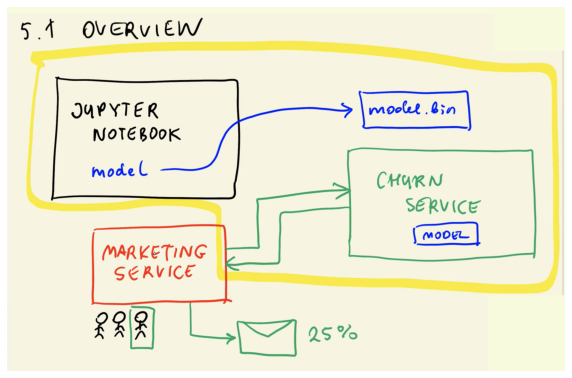

In [12]:
from PIL import Image
import matplotlib.pyplot as plt
img = Image.open('chapter_overview5.png')
plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.axis('off')
plt.show()

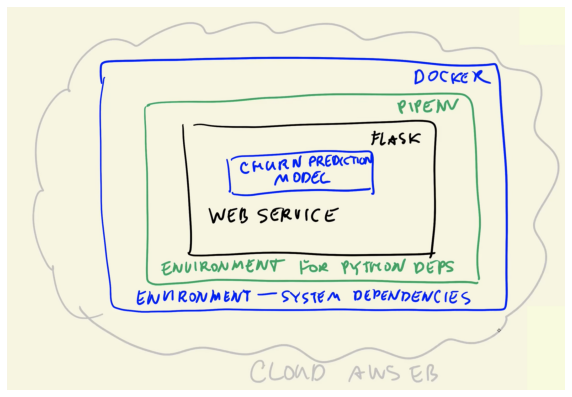

In [13]:
from PIL import Image
import matplotlib.pyplot as plt
img1 = Image.open('chapter_overview5_part2.png')
plt.figure(figsize=(10, 8))
plt.imshow(img1)
plt.axis('off')
plt.show()

## [5.2 Saving and loading the model](https://www.youtube.com/watch?v=EJpqZ7OlwFU&list=PL3MmuxUbc_hIhxl5Ji8t4O6lPAOpHaCLR&index=52)

- Saving the model to pickle
- Loading the model from pickle
- Turning our notebook into a Python script

In [14]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold

from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

In [15]:
csv_url = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-03-churn-prediction/WA_Fn-UseC_-Telco-Customer-Churn.csv'
df = pd.read_csv(csv_url)

In [16]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

categorical_columns = list(df.dtypes[df.dtypes == 'object'].index)

for c in categorical_columns:
    df[c] = df[c].str.lower().str.replace(' ', '_')

df.totalcharges = pd.to_numeric(df.totalcharges, errors = 'coerce')
df.totalcharges = df.totalcharges.fillna(0)

df.churn = (df.churn == 'yes').astype(int)

In [17]:
df_full_train, df_test = train_test_split(df, test_size = 0.2, random_state = 1)

In [18]:
numerical = ['tenure', 'monthlycharges', 'totalcharges']
categorical = [
     'gender',
     'seniorcitizen',
     'partner',
     'dependents',
     'phoneservice',
     'multiplelines',
     'internetservice',
     'onlinesecurity',
     'onlinebackup',
     'deviceprotection',
     'techsupport',
     'streamingtv',
     'streamingmovies',
     'contract',
     'paperlessbilling',
     'paymentmethod',
              ]

In [19]:
def train(df_train, y_train, C = 1.0):
    dicts = df_train[categorical + numerical].to_dict(orient = 'records')
    
    dv = DictVectorizer(sparse = False)
    X_train = dv.fit_transform(dicts)
    
    model = LogisticRegression(C = C, max_iter = 1000)
    model.fit(X_train, y_train)
    
    return dv, model

In [20]:
def predict(df, dv, model):
    dicts = df[categorical + numerical].to_dict(orient = 'records')
    
    X = dv.transform(dicts)
    
    y_pred = model.predict_proba(X)[:, 1]
    return y_pred

In [21]:
C = 1.0
n_splits = 5

In [22]:
kfold = KFold(n_splits = n_splits, shuffle = True, random_state = 1)
    
scores = []

for train_idx, val_idx in kfold.split(df_full_train):
    df_train = df_full_train.iloc[train_idx]
    df_val = df_full_train.iloc[val_idx]

    y_train = df_train.churn.values
    y_val = df_val.churn.values

    dv, model = train(df_train, y_train, C = C)
    y_pred = predict(df_val, dv, model)

    auc = roc_auc_score(y_val, y_pred)
    scores.append(auc)

print('C=%s %.3f +- %.3f' % (C, np.mean(scores), np.std(scores)))

C=1.0 0.841 +- 0.009


In [23]:
scores

[0.8435839266510193,
 0.8458378857105019,
 0.8311780052177403,
 0.8301724275756219,
 0.8526795519437733]

In [24]:
dv, model = train(df_full_train, df_full_train.churn.values, C=1.0)
y_pred = predict(df_test, dv, model)
y_test = df_test.churn.values

auc = roc_auc_score(y_test, y_pred)
auc

0.8572386167896259

### Save the model

In [25]:
import pickle

In [26]:
output_file = f'model_C={C}.bin'
output_file

'model_C=1.0.bin'

In [27]:
with open(output_file, 'wb') as f_out:
    pickle.dump((dv,model), f_out)

### Load the model

In [35]:
import pickle

In [36]:
model_file = 'model_C=1.0.bin'

In [37]:
with open(model_file, 'rb') as f_in:
    dv,model = pickle.load(f_in)

In [38]:
dv,model

(DictVectorizer(sparse=False), LogisticRegression(max_iter=1000))

In [39]:
customer = {
    'gender':'female',
    'seniorcitizen': 0,
    'partner': 'yes',
    'dependents': 'no',
    'phoneservice': 'no',
    'multiplelines': 'no_phone_service',
    'internetservice': 'dsl',
    'onlinesecurity': 'no',
    'onlinebackup': 'yes',
    'deviceprotection': 'no',
    'techsupport': 'no',
    'streamingtv': 'no',
    'streamingmovies': 'no',
    'contract': 'month-to-month',
    'paperlessbilling': 'yes',
    'paymentmethod': 'electronic_check',
    'tenure': 1,
    'monthlycharges': 29.85,
    'totalcharges': 29.85
}

In [41]:
X = dv.transform([customer])

In [43]:
model.predict_proba(X)[0, 1]

0.63635841526415

## [5.3 Web services: introduction to Flask](https://www.youtube.com/watch?v=W7ubna1Rfv8&list=PL3MmuxUbc_hIhxl5Ji8t4O6lPAOpHaCLR&index=53)

- Writing a simple ping/pong app
- Queryting it with `curl` and browser


- `curl http://0.0.0.0:9696/ping`  
- `curl http://localhost:9696/ping`

## [5.4 Serving the model with Flask](https://www.youtube.com/watch?v=Q7ZWPgPnRz8&list=PL3MmuxUbc_hIhxl5Ji8t4O6lPAOpHaCLR&index=54)
- Wrapping the predict script into a Flask app
- Querying it with `requests`
- Preparing for production: gunicorn
- Running it on Windows with waitress

- `pip install gunicorn`
- `gunicorn --bind 0.0.0.0:9696 predict:app`

- Gincorn is used for production deplyment. Second line explanation: we need to specify where the app lives (localhost:9696) and we also need to explain which script to run, which is `predict.py`
- For windows machines, use `waitress` with:
    - `pip install waitress`
    - `waitress-serve --listen=0.0.0.0:9696 predict:app`

To run the whole thing, first activate the predict app, and then test it!:
- `cd chapter_5`
- `python predict.py`
- **In a separate terminal** `python predict-test.py`

## [5.5 Dependency and environment management: Pipenv](https://www.youtube.com/watch?v=BMXh8JGROHM&list=PL3MmuxUbc_hIhxl5Ji8t4O6lPAOpHaCLR&index=55)
- Why we need virtual environment
- Installing Pipenv
- Installing libraries with Pipenv
- Running things with Pipenv

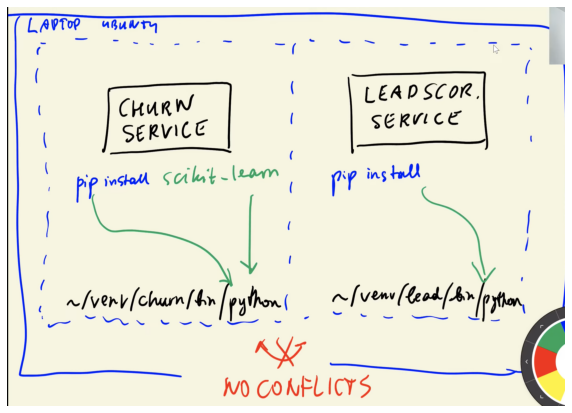

In [46]:
from PIL import Image
import matplotlib.pyplot as plt
img2 = Image.open('separation_of_environments.png')
plt.figure(figsize=(10, 8))
plt.imshow(img2)
plt.axis('off')
plt.show()

- `pip install pipenv`

Then we start installing all of the packages needed for our project:
- `pipenv install flask numpy scikit-learn`

**In a separate terminal**
- `pipenv install gunicorn`

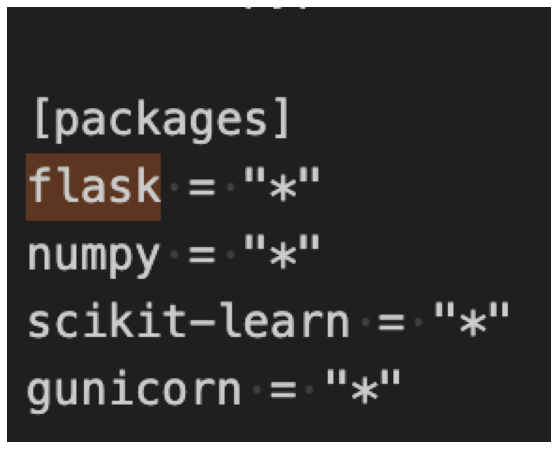

In [58]:
from PIL import Image
import matplotlib.pyplot as plt
img3 = Image.open('expected_packages_pipfile.png')
plt.figure(figsize=(10, 8))
plt.imshow(img3)
plt.axis('off')
plt.show()

## [5.6 Environment Management: Docker](https://www.youtube.com/watch?v=wAtyYZ6zvAs&list=PL3MmuxUbc_hIhxl5Ji8t4O6lPAOpHaCLR&index=56)
- Why we need Docker
- Running a Pythong image with Docker
- Dockerfile
- Building a docker image
- Running a docker image

In [59]:
import sklearn
print(sklearn.__version__)

1.1.0


In [64]:
import sys
print(sys.version)

3.9.13 (main, Oct 13 2022, 16:12:30) 
[Clang 12.0.0 ]


In [65]:
import numpy
print(numpy.__version__)

1.26.1


In [66]:
import flask
print(flask.__version__)

2.1.3


In [67]:
import gunicorn
print(gunicorn.__version__)

20.1.0


Anyways, here's what the dockerfile looks like:
```dockerfile
FROM python:3.9-slim
WORKDIR /app
COPY requirements.txt .
RUN pip install -r requirements.txt
COPY ["predict.py", "model_C=1.0.bin", "./"]
EXPOSE 9696
ENTRYPOINT ["gunicorn", "--bind=0.0.0.0:9696", "predict:app"]
```

execution steps:
- **Clean up**
    - `rm Pipfile.lock`
    - `docker rmi zoomcamp-test`
- **Rebuild**
    - `docker build -t zoomcamp-test .`
    - `docker run -it --rm -p 9696:9696 zoomcamp-test`
- **In a separate terminal**
    - `python predict-test.py`

I did this my way without Pipfile and Pipfile.lock

## [5.7 Deployment to the cloud: AWS Elastic Beanstalk (optional)](https://www.youtube.com/watch?v=HGPJ4ekhcLg&list=PL3MmuxUbc_hIhxl5Ji8t4O6lPAOpHaCLR&index=57)
- Installing the eb cli
- Running eb locally
- Deploying the model
